# Notebook 4: Phase 3a - Endangered Species Specialization

**Sequential Transfer Learning for Medicinal Plant Identification**

---

## Purpose

Fine-tune on Dataset 4 (REMP - Rare & Endangered Medicinal Plants of Bangladesh).

**Dataset 4 Info:**
- 16 rare/endangered species from Bangladesh
- ~3,494 images
- Source: REMP dataset (Mendeley Data)

```
Phase 1: General Features (Dataset 1)        DONE
    |
Phase 2: Regional Context (Dataset 2)         DONE
    |
Phase 3a: Endangered Species (Dataset 4)  <-- WE ARE HERE
    |
Phase 3b: Commercial Species (Dataset 5)
```

---

## KEY: True Sequential Transfer Learning

We load the **Phase 2 trained model** and transfer its learned features.
The base ResNet50 now carries knowledge from:
- ImageNet (general visual features)
- Dataset 1 (general medicinal plant features)
- Dataset 2 (Bangladesh regional features)

**Target: Endangered species recall >= 95%**

---

**Prerequisites:**
- Run notebooks 01, 02, 03 first
- `models/phase2_regional.keras` must exist in Google Drive
- GPU required: Runtime -> Change runtime type -> GPU

## 1. Mount Google Drive & Setup

In [3]:
# Mount Google Drive
from google.colab import drive

print(">>> Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)
print(">>>>> Google Drive mounted!")

>>> Mounting Google Drive...
Mounted at /content/drive
>>>>> Google Drive mounted!


In [4]:
# Import libraries
import os
import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f">>> GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # avoid OOM
else:
    print("WARNING: No GPU! Go to Runtime -> Change runtime type -> GPU")

TensorFlow version: 2.19.0
>>> GPU detected: /physical_device:GPU:0


In [5]:
# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.00005  # very low LR for fine-tuning endangered species
VALIDATION_SPLIT = 0.2
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Google Drive paths
DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

# Phase 2 model path (what we are loading from)
PHASE2_MODEL_PATH = os.path.join(MODEL_DIR, "phase2_regional.keras")

os.makedirs(MODEL_DIR, exist_ok=True)

print(">>> Configuration loaded")
print(f"   Learning rate: {LEARNING_RATE} (very low for fine-tuning)")
print(f"   Project: {PROJECT_DIR}")

>>> Configuration loaded
   Learning rate: 5e-05 (very low for fine-tuning)
   Project: /content/drive/MyDrive/MedicinalPlant_Dissertation


## 2. Load Phase 2 Model (Sequential Transfer)

This is the **critical step** for sequential transfer learning.
We load the Phase 2 model which already contains knowledge from:
- ImageNet -> Dataset 1 -> Dataset 2

We extract the ResNet50 base (with its updated weights) and build
a new classification head for 16 endangered species.

In [6]:
# Load Phase 2 model
if not os.path.exists(PHASE2_MODEL_PATH):
    raise FileNotFoundError(
        f"Phase 2 model not found!\n"
        f"Expected: {PHASE2_MODEL_PATH}\n\n"
        "Please run 03_phase2_regional.ipynb first!"
    )

print(f">>> Loading Phase 2 model from Google Drive...")
print(f"   {PHASE2_MODEL_PATH}")

phase2_model = keras.models.load_model(PHASE2_MODEL_PATH)

print(f"\n>>>>> Phase 2 model loaded!")
print(f"   Layers: {len(phase2_model.layers)}")
try:
    print(f"   Output classes: {phase2_model.output_shape[-1]}")
except:
    pass

# Show layer names to identify the ResNet50 base
print(f"\n   Model layers:")
for i, layer in enumerate(phase2_model.layers):
    try:
        if hasattr(layer, 'output_shape'):
             print(f"     [{i}] {layer.name} - trainable: {layer.trainable} - output: {layer.output_shape}")
        else:
             print(f"     [{i}] {layer.name} - trainable: {layer.trainable}")
    except:
        print(f"     [{i}] {layer.name} - trainable: {layer.trainable}")

>>> Loading Phase 2 model from Google Drive...
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase2_regional.keras

>>>>> Phase 2 model loaded!
   Layers: 9
   Output classes: 6

   Model layers:
     [0] augmentation - trainable: True - output: (None, 224, 224, 3)
     [1] resnet50 - trainable: False - output: (None, 7, 7, 2048)
     [2] global_average_pooling2d - trainable: True
     [3] batch_normalization - trainable: True
     [4] dropout - trainable: True
     [5] dense - trainable: True
     [6] batch_normalization_1 - trainable: True
     [7] dropout_1 - trainable: True
     [8] dense_1 - trainable: True


In [7]:
# Extract the ResNet50 base with Phase 2 learned weights
# Sequential models: index 0 = Input, 1 = augmentation, 2 = resnet50

resnet_base = None
for layer in phase2_model.layers:
    if 'resnet' in layer.name.lower():
        resnet_base = layer
        break

if resnet_base is None:
    # fallback: look for any layer with lots of sub-layers
    for layer in phase2_model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 10:
            resnet_base = layer
            break

if resnet_base is not None:
    print(f">>> Extracted ResNet50 base from Phase 2")
    print(f"   Name: {resnet_base.name}")
    print(f"   Parameters: {resnet_base.count_params():,}")
    print(f"   This base carries knowledge from: ImageNet -> Dataset 1 -> Dataset 2")
else:
    print("WARNING: Could not extract ResNet50 base. Will use fresh ImageNet weights.")
    print("(This means we lose the sequential transfer advantage)")

>>> Extracted ResNet50 base from Phase 2
   Name: resnet50
   Parameters: 23,587,712
   This base carries knowledge from: ImageNet -> Dataset 1 -> Dataset 2


## 3. Find and Load Dataset 4 (REMP Endangered)

In [8]:
# Extract Dataset 4 if needed
import zipfile

zip_path = os.path.join(DATA_DIR, "dataset4.zip")
extract_dir = os.path.join(DATA_DIR, "dataset4")

if os.path.exists(extract_dir) and os.listdir(extract_dir):
    print(f">>>>> Dataset 4 already extracted - SKIPPING")
else:
    print(">>> Extracting dataset4.zip...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    # Handle nested zips
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if file.endswith('.zip'):
                nested = os.path.join(root, file)
                print(f"   Extracting nested: {file}")
                with zipfile.ZipFile(nested, 'r') as z:
                    z.extractall(root)
                os.remove(nested)
    print(">>>>> Dataset 4 extracted!")

>>>>> Dataset 4 already extracted - SKIPPING


In [9]:
# Find image directory
def find_image_directory(base_dir):
    """Find the directory containing class folders with images."""
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
                           for f in sample_files)
            if has_images:
                return root
    return None

# Find Dataset 4
print(">>> Finding Dataset 4 (REMP Endangered)...")

# try config first
config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
DATASET4_PATH = None

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
    DATASET4_PATH = config.get("dataset_paths", {}).get("dataset4")

if not DATASET4_PATH or not os.path.exists(DATASET4_PATH):
    dataset4_base = os.path.join(DATA_DIR, "dataset4")
    DATASET4_PATH = find_image_directory(dataset4_base)

if DATASET4_PATH and os.path.exists(DATASET4_PATH):
    classes = sorted([d for d in os.listdir(DATASET4_PATH)
                      if os.path.isdir(os.path.join(DATASET4_PATH, d)) and not d.startswith('.')])
    print(f"\n>>>>> Dataset 4 found!")
    print(f"   Path: {DATASET4_PATH}")
    print(f"   Classes: {len(classes)}")
    print(f"   Species: {classes}")
else:
    raise FileNotFoundError("Dataset 4 not found! Run 01_data_exploration.ipynb first.")

>>> Finding Dataset 4 (REMP Endangered)...

>>>>> Dataset 4 found!
   Path: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset4/REMP A Unique Dataset of Rare and Endangered Medicinal Plants in Bangladesh/Raw-Images
   Classes: 16
   Species: ['type_1', 'type_10', 'type_11', 'type_12', 'type_13', 'type_14', 'type_15', 'type_16', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6', 'type_7', 'type_8', 'type_9']


In [10]:
# Load Dataset 4
print(f">>> Loading Dataset 4 (REMP - {len(classes)} endangered species)...\n")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET4_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET4_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print(f">>>>> Dataset 4 loaded!")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Class names: {class_names}")

>>> Loading Dataset 4 (REMP - 16 endangered species)...

Found 1713 files belonging to 16 classes.
Using 1371 files for training.
Found 1713 files belonging to 16 classes.
Using 342 files for validation.
>>>>> Dataset 4 loaded!
   Classes: 16
   Class names: ['type_1', 'type_10', 'type_11', 'type_12', 'type_13', 'type_14', 'type_15', 'type_16', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6', 'type_7', 'type_8', 'type_9']


In [11]:
# Check class distribution (important for endangered species - might be imbalanced)
print("\nClass Distribution (Dataset 4 - Endangered):")
print("=" * 50)

class_counts = {}
for class_name in class_names:
    class_path = os.path.join(DATASET4_PATH, class_name)
    count = len([f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    class_counts[class_name] = count
    print(f"   {class_name}: {count} images")

total = sum(class_counts.values())
print(f"\n   Total: {total} images")
print(f"   Min per class: {min(class_counts.values())}")
print(f"   Max per class: {max(class_counts.values())}")
print(f"   Imbalance ratio: {max(class_counts.values()) / max(min(class_counts.values()), 1):.1f}x")


Class Distribution (Dataset 4 - Endangered):
   type_1: 201 images
   type_10: 0 images
   type_11: 0 images
   type_12: 134 images
   type_13: 151 images
   type_14: 154 images
   type_15: 108 images
   type_16: 0 images
   type_2: 0 images
   type_3: 0 images
   type_4: 0 images
   type_5: 0 images
   type_6: 294 images
   type_7: 276 images
   type_8: 238 images
   type_9: 157 images

   Total: 1713 images
   Min per class: 0
   Max per class: 294
   Imbalance ratio: 294.0x


In [12]:
# Compute class weights to handle imbalance
# Class weights - penalizes missing rare species more
print(">>> Computing class weights for imbalanced data...")

total_images = sum(class_counts.values())
n_classes = len(class_counts)

class_weight_dict = {}

if n_classes == 0:
    print("WARNING: No classes found! Cannot compute class weights.")
else:
    for i, class_name in enumerate(class_names):
        # Use max(1, count) to avoid division by zero if a folder is empty
        count = class_counts.get(class_name, 0)
        safe_count = max(1, count)

        weight = total_images / (n_classes * safe_count)  # inverse frequency weighting
        class_weight_dict[i] = weight

    print("\nClass weights (higher = model pays more attention):")
    for i, class_name in enumerate(class_names):
        weight = class_weight_dict.get(i, 0)
        print(f"   {class_name}: {weight:.3f}")

print("\nRare species get higher weights so the model focuses on getting them right")

>>> Computing class weights for imbalanced data...

Class weights (higher = model pays more attention):
   type_1: 0.533
   type_10: 107.062
   type_11: 107.062
   type_12: 0.799
   type_13: 0.709
   type_14: 0.695
   type_15: 0.991
   type_16: 107.062
   type_2: 107.062
   type_3: 107.062
   type_4: 107.062
   type_5: 107.062
   type_6: 0.364
   type_7: 0.388
   type_8: 0.450
   type_9: 0.682

Rare species get higher weights so the model focuses on getting them right


In [13]:
# Preprocessing
normalization = layers.Rescaling(1./255)  # scale to [0,1]
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x, y: (normalization(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(">>> Datasets normalized and cached")

>>> Datasets normalized and cached


## 4. Build Phase 3a Model

We reuse the ResNet50 base from Phase 2 (carrying knowledge from Phases 1 & 2)
and build a new classification head for 16 endangered species.

**Key difference from Phase 2:**
- We partially unfreeze the ResNet50 top layers for fine-tuning
- We use class weights to prioritize rare species
- Target: maximum recall (catch every endangered species)

In [14]:
# Build Phase 3a model using the Phase 2 ResNet50 base
print(">>> Building Phase 3a model (Endangered Species)...")
print("   Transfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a\n")

# Use extracted base if available, fresh ResNet50 as fallback
if resnet_base is not None:
    print("   Using Phase 2 ResNet50 base (sequential transfer)")
    base = resnet_base
else:
    print("   WARNING: Using fresh ImageNet ResNet50 (no sequential transfer)")
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Partially unfreeze top layers for fine-tuning
base.trainable = True
total_layers = len(base.layers)
fine_tune_from = total_layers - 30  # unfreeze last 30 layers

for layer in base.layers[:fine_tune_from]:
    layer.trainable = False

trainable_count = sum(1 for l in base.layers if l.trainable)
print(f"   Base layers: {total_layers}")
print(f"   Trainable layers: {trainable_count}")
print(f"   Frozen layers: {total_layers - trainable_count}")

# Stronger augmentation for endangered species (need robustness)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1),
], name="augmentation_endangered")

# Build model
model = keras.Sequential([
    keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),   # wider FC layer for 16 classes
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')  # output for endangered species
], name="phase3a_endangered")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print(f"\n>>>>> Model built for {NUM_CLASSES} endangered species")
model.summary()

>>> Building Phase 3a model (Endangered Species)...
   Transfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a

   Using Phase 2 ResNet50 base (sequential transfer)
   Base layers: 175
   Trainable layers: 30
   Frozen layers: 145

>>>>> Model built for 16 endangered species


Model: "phase3a_endangered"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_endangered         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,783,504 (94.54 MB)

 Trainable params: 15,640,336 (59.66 MB)

 Non-trainable params: 9,143,168 (34.88 MB)

## 5. Train Phase 3a

In [15]:
# Callbacks - monitoring recall since this is endangered species
MODEL_PATH = os.path.join(MODEL_DIR, "phase3a_endangered.keras")

callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_recall', mode='max',
                    save_best_only=True, verbose=1),  # save best recall model
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4,
                      min_lr=1e-7, verbose=1)
]

print(f">>> Model will be saved to Google Drive:")
print(f"   {MODEL_PATH}")
print(f"   Monitoring: val_recall (max) - prioritizing endangered species detection")

>>> Model will be saved to Google Drive:
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3a_endangered.keras
   Monitoring: val_recall (max) - prioritizing endangered species detection


In [16]:
# Train with class weights to handle imbalanced data
print("\n" + "="*50)
print(">>>>> STARTING PHASE 3a TRAINING (ENDANGERED SPECIES)")
print("="*50)
print(f"Dataset: Dataset 4 - REMP ({NUM_CLASSES} endangered species)")
print(f"Transfer: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a")
print(f"Class weights: ENABLED (rare species prioritized)")
print("="*50 + "\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # handle class imbalance
    verbose=1
)

print("\n" + "="*50)
print(">>>>> PHASE 3a TRAINING COMPLETE!")
print("="*50)


>>>>> STARTING PHASE 3a TRAINING (ENDANGERED SPECIES)
Dataset: Dataset 4 - REMP (16 endangered species)
Transfer: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a
Class weights: ENABLED (rare species prioritized)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.0674 - loss: 2.1070 - precision: 0.0957 - recall: 0.0169
Epoch 1: val_recall improved from -inf to 0.00000, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3a_endangered.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 417s 9s/step - accuracy: 0.0677 - loss: 2.1047 - precision: 0.0965 - recall: 0.0170 - val_accuracy: 0.1637 - val_loss: 2.8205 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.0922 - loss: 1.9074 - precision: 0.1769 - recall: 0.0243
Epoch 2: val_recall did not improve from 0.00000
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 0.0924 - loss: 1.9064 - precision: 0.1769 - recall: 0.0243 - v

## 6. Results & Evaluation

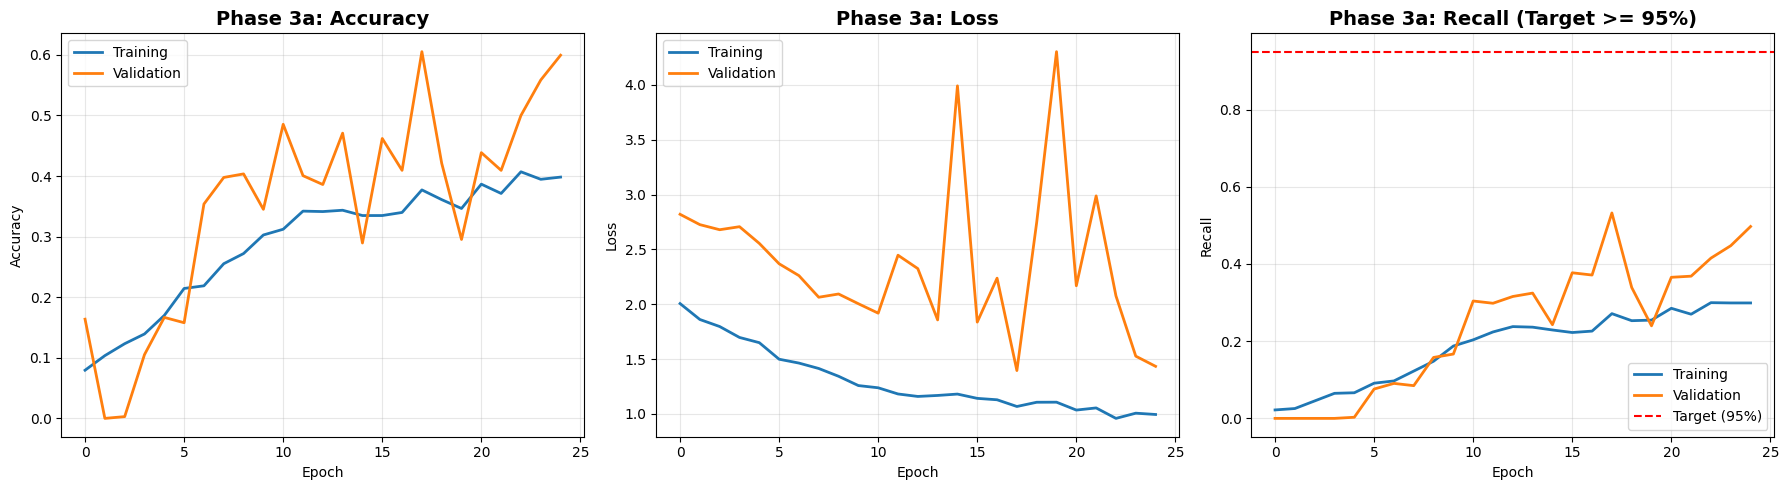

In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Phase 3a: Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Phase 3a: Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Recall (key metric for endangered species)
axes[2].plot(history.history['recall'], label='Training', linewidth=2)
axes[2].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[2].axhline(y=0.95, color='r', linestyle='--', label='Target (95%)')
axes[2].set_title('Phase 3a: Recall (Target >= 95%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Recall')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase3a_training_curves.png'), dpi=150)
plt.show()

In [21]:
# Detailed evaluation
# Re-compile to ensure metrics are named correctly in Keras 3
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

val_results = model.evaluate(val_dataset, verbose=0)

print(">>> Phase 3b Results (Commercial Species)")
print("=" * 50)

metric_map = {}
# If names are still generic (keras 3 issue), map manually based on known compile order
# Order is typically: [loss, accuracy, precision, recall]
if len(val_results) == 4 and 'accuracy' not in model.metrics_names:
    print("   (Applying manual metric names due to Keras version)")
    manual_names = ['loss', 'accuracy', 'precision', 'recall']
    for name, value in zip(manual_names, val_results):
        print(f"   {name}: {value:.4f}")
        metric_map[name] = value
else:
    for name, value in zip(model.metrics_names, val_results):
        print(f"   {name}: {value:.4f}")
        metric_map[name] = value
print("=" * 50)

# Check against precision target
# Prefer 'val_precision' from history if evaluate fails to provide name
if 'precision' in metric_map:
    val_precision = metric_map['precision']
elif 'val_precision' in history.history:
    val_precision = history.history['val_precision'][-1]
    print(f"   (Using last validation precision from history: {val_precision:.4f})")
else:
    val_precision = 0.0

if val_precision > 0:
    if val_precision >= 0.95:
        print(f"\n   PRECISION TARGET MET: {val_precision*100:.1f}% >= 95%")
    else:
        print(f"\n   PRECISION BELOW TARGET: {val_precision*100:.1f}% < 95%")
        print(f"   Gap: {(0.95 - val_precision)*100:.1f} percentage points")
else:
    print("\nWARNING: Precision metric not found.")

>>> Phase 3b Results (Commercial Species)
   (Applying manual metric names due to Keras version)
   loss: 1.3955
   accuracy: 0.6053
   precision: 0.6894
   recall: 0.5322

   PRECISION BELOW TARGET: 68.9% < 95%
   Gap: 26.1 percentage points


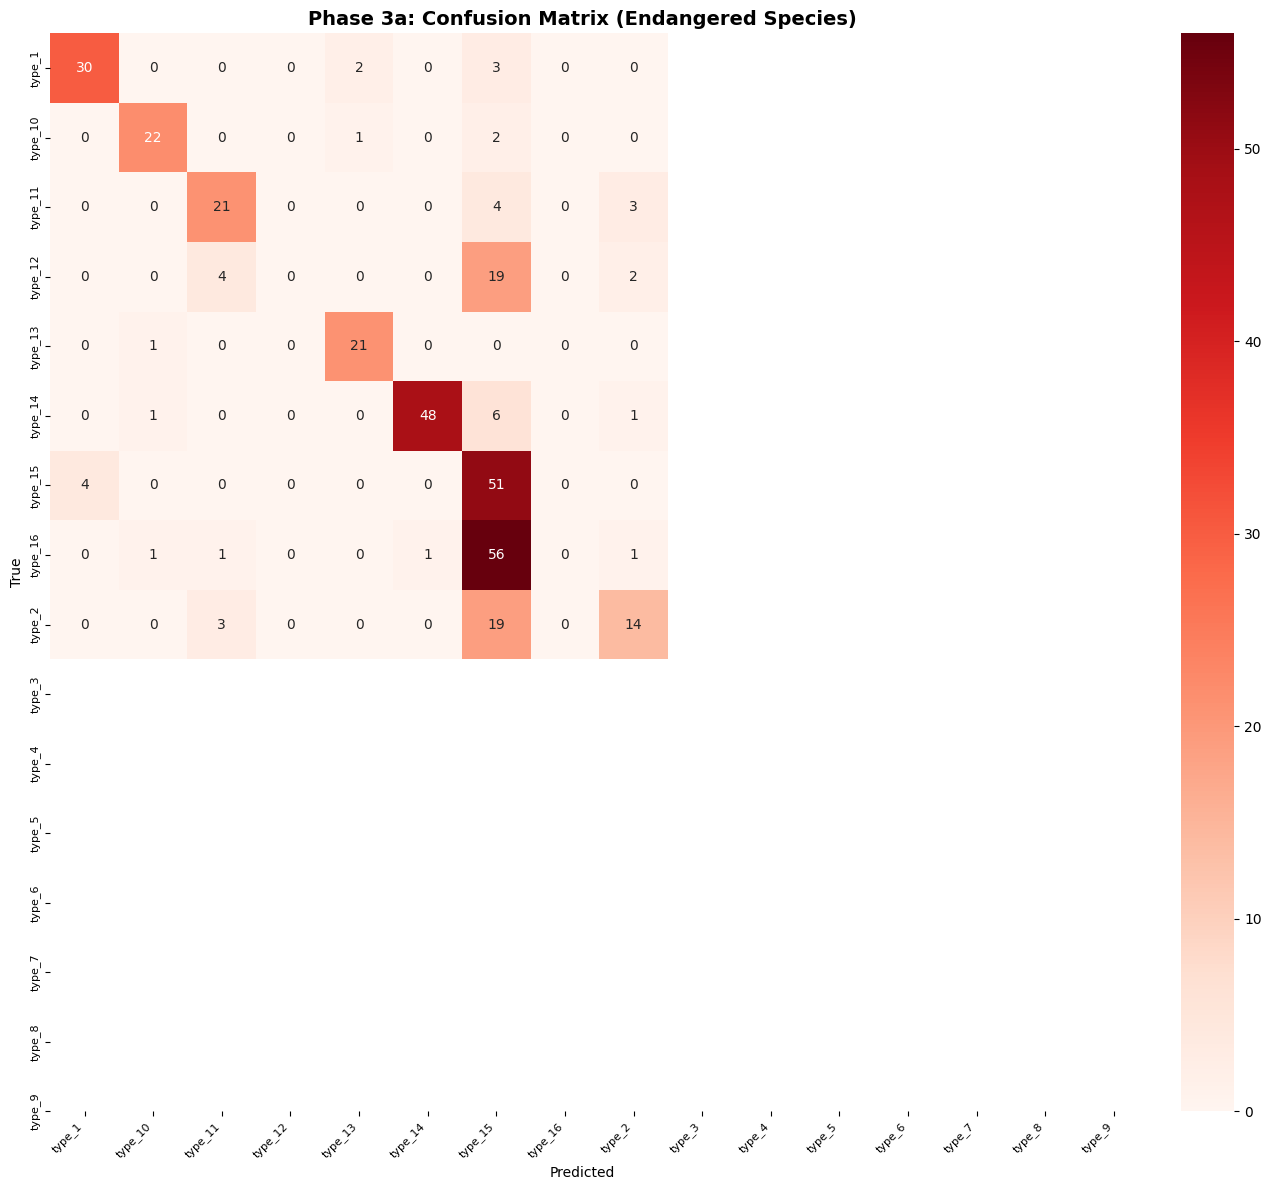

In [22]:
# Confusion matrix
y_true, y_pred = [], []
for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Phase 3a: Confusion Matrix (Endangered Species)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase3a_confusion_matrix.png'), dpi=150)
plt.show()

In [25]:
# Per-species classification report
print("Per-Species Classification Report (Commercial)")
print("=" * 70)

# Calculate unique classes found in predictions
unique_labels = sorted(list(set(y_true) | set(y_pred)))
print(f"Classes present in validation set: {len(unique_labels)} / {len(class_names)}")

# Use labels parameter to force all classes to be reported (even if missing)
# Zero_division=0 handles classes with no samples
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    labels=range(len(class_names)),
    digits=3,
    zero_division=0
)
print(report)

# Highlight species with low precision
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    labels=range(len(class_names)),
    output_dict=True,
    zero_division=0
)

print("\n--- COMMERCIAL SPECIES PRECISION CHECK ---")
for species in class_names:
    if species in report_dict:
        prec_val = report_dict[species]['precision']
        support = report_dict[species]['support']

        status = "PASS" if prec_val >= 0.95 else "NEEDS ATTENTION"
        if support == 0:
            status = "NO DATA (Skipped)"

        print(f"   {species}: {prec_val*100:.1f}% precision (n={support}) [{status}]")

Per-Species Classification Report (Commercial)
Classes present in validation set: 9 / 16
              precision    recall  f1-score   support

      type_1      0.882     0.857     0.870        35
     type_10      0.000     0.000     0.000         0
     type_11      0.000     0.000     0.000         0
     type_12      0.880     0.880     0.880        25
     type_13      0.724     0.750     0.737        28
     type_14      0.000     0.000     0.000        25
     type_15      0.875     0.955     0.913        22
     type_16      0.000     0.000     0.000         0
      type_2      0.000     0.000     0.000         0
      type_3      0.000     0.000     0.000         0
      type_4      0.000     0.000     0.000         0
      type_5      0.000     0.000     0.000         0
      type_6      0.980     0.857     0.914        56
      type_7      0.319     0.927     0.474        55
      type_8      0.000     0.000     0.000        60
      type_9      0.667     0.389     0.491   

## 7. Save Model & Artifacts

In [26]:
# Save model to Google Drive
model.save(MODEL_PATH)
print(f">>>>> Model saved: {MODEL_PATH}")

# Save class names
with open(os.path.join(MODEL_DIR, "phase3a_class_names.json"), 'w') as f:
    json.dump(class_names, f)

# Save training history
with open(os.path.join(MODEL_DIR, "phase3a_history.json"), 'w') as f:
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    json.dump(history_dict, f)

# Save per-species metrics for analysis
with open(os.path.join(MODEL_DIR, "phase3a_species_metrics.json"), 'w') as f:
    json.dump(report_dict, f, indent=2)

# Update config
config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
else:
    config = {"dataset_paths": {}}

config["dataset_paths"]["dataset4"] = DATASET4_PATH
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("\n>>>>> All Phase 3a artifacts saved to Google Drive")
print(f"   - {MODEL_PATH}")
print(f"   - phase3a_class_names.json")
print(f"   - phase3a_history.json")
print(f"   - phase3a_species_metrics.json")

>>>>> Model saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3a_endangered.keras

>>>>> All Phase 3a artifacts saved to Google Drive
   - /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3a_endangered.keras
   - phase3a_class_names.json
   - phase3a_history.json
   - phase3a_species_metrics.json


## 8. Summary

### Phase 3a Complete!

**Sequential Transfer Chain:**
```
ImageNet -> Dataset 1 (General) -> Dataset 2 (Regional) -> Dataset 4 (Endangered)
```

**Saved to Google Drive:**
- `models/phase3a_endangered.keras`
- Training curves and confusion matrix
- Per-species recall metrics

### Next Step:
Open `05_phase3b_commercial.ipynb` to fine-tune for commercial species (Dataset 5)

In [27]:
print("\n" + "="*60)
print(">>>>> PHASE 3a COMPLETE! (Endangered Species)")
print("="*60)
print(f"\n>>> Results:")
print(f"   Accuracy: {max(history.history['val_accuracy'])*100:.1f}%")
print(f"   Best Recall: {max(history.history['val_recall'])*100:.1f}%")
print(f"   Species: {NUM_CLASSES} endangered species")
print(f"\nTransfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a")
print(f"\nModel saved: {MODEL_PATH}")
print(f"\nNext: Open 05_phase3b_commercial.ipynb")


>>>>> PHASE 3a COMPLETE! (Endangered Species)

>>> Results:
   Accuracy: 60.5%
   Best Recall: 53.2%
   Species: 16 endangered species

Transfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a

Model saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3a_endangered.keras

Next: Open 05_phase3b_commercial.ipynb
